# Model Comparison

This notebook consolidates already-saved model results for the audio deepfake detection experiments. It compares model artifacts that have already been produced by the individual training notebooks and does not train, tune, or retrain any model.

Use this notebook after the model notebooks have written their metrics under `outputs/<model>/metrics` and validation tables under `outputs/<model>/tables`. The only cell that should normally need editing is the configuration cell.

## Purpose and Guardrails

This notebook is a reporting and audit notebook, not a training notebook.

- It reads saved JSON metrics first and falls back to CSV metrics when that is the format available.
- It validates run mode from filenames and explicit metadata when present.
- It does not silently mix `smoke`, `validation`, and `final` results.
- It reports missing models and skipped files before ranking models.
- It ranks only from loaded metric files, so it does not perform test-driven model selection.
- It makes no performance claims beyond the values present in saved metric files or values that can be computed directly from saved confusion matrices.

For this repository, the discovered conventions are `outputs/<model>/metrics/<model>_test_metrics.json`, `outputs/<model>/metrics/<model>_confusion_matrix.csv`, and `outputs/<model>/tables/<model>_validation_experiments.csv`.

## Configuration

Update this cell if the notebook is moved, if output folders are renamed, or if you want to compare `smoke`, `validation`, or `final` results.

In [1]:
from pathlib import Path

# Root of the repository. If this notebook is run from the repo root, Path.cwd() is correct.
PROJECT_ROOT = Path.cwd()
OUTPUT_ROOT = PROJECT_ROOT / "outputs"

# Choose one: "smoke", "validation", or "final".
# In this repo, final model results are saved as *_test_metrics.json files.
RUN_MODE = "final"

# Optional dataset guard. Leave as None when existing metric files do not record dataset metadata.
# If set, files with a different dataset_id/dataset/name are skipped, and files with missing
# dataset metadata are reported rather than silently accepted.
EXPECTED_DATASET_ID = None

# Comparison artifacts are saved under OUTPUT_ROOT / COMPARISON_OUTPUT_FOLDER.
COMPARISON_OUTPUT_FOLDER = "comparison"

# Expected models discovered from the repository notebooks and output folders.
# output_folders can include future aliases so the notebook works if a model folder is renamed.
MODEL_SPECS = [
    {
        "model_name": "SVM",
        "metric_stem": "svm",
        "output_folders": ["svm", "support_vector_machine"],
        "category": "core",
        "required": True,
    },
    {
        "model_name": "MLP",
        "metric_stem": "mlp",
        "output_folders": ["mlp"],
        "category": "core",
        "required": True,
    },
    {
        "model_name": "CNN",
        "metric_stem": "cnn",
        "output_folders": ["cnn"],
        "category": "core",
        "required": True,
    },
    {
        "model_name": "Logistic Regression",
        "metric_stem": "logistic_regression",
        "output_folders": ["logistic_regression", "logistic"],
        "category": "optional_baseline",
        "required": False,
    },
    {
        "model_name": "Random Forest",
        "metric_stem": "random_forest",
        "output_folders": ["random_forest"],
        "category": "optional_baseline",
        "required": False,
    },
    {
        "model_name": "XGBoost",
        "metric_stem": "xgboost",
        "output_folders": ["xgboost"],
        "category": "optional_baseline",
        "required": False,
    },
    {
        "model_name": "LSTM Optional",
        "metric_stem": "lstm",
        "output_folders": ["lstm_optional", "lstm"],
        "category": "optional_sequence_model",
        "required": False,
    },
]

# Filename patterns are checked in order. JSON is preferred over CSV when both exist.
EXPECTED_METRIC_FILENAME_PATTERNS = {
    "final": {
        "json": [
            "{stem}_test_metrics.json",
            "{folder}_test_metrics.json",
            "{stem}_final_metrics.json",
            "{folder}_final_metrics.json",
            "test_metrics.json",
            "final_metrics.json",
        ],
        "csv": [
            "{stem}_test_metrics.csv",
            "{folder}_test_metrics.csv",
            "{stem}_final_metrics.csv",
            "{folder}_final_metrics.csv",
            "test_metrics.csv",
            "final_metrics.csv",
        ],
    },
    "validation": {
        "json": [
            "{stem}_validation_metrics.json",
            "{folder}_validation_metrics.json",
            "validation_metrics.json",
        ],
        "csv": [
            "{stem}_validation_metrics.csv",
            "{folder}_validation_metrics.csv",
            "{stem}_validation_experiments.csv",
            "{folder}_validation_experiments.csv",
            "validation_metrics.csv",
            "validation_experiments.csv",
        ],
    },
    "smoke": {
        "json": [
            "{stem}_smoke_metrics.json",
            "{folder}_smoke_metrics.json",
            "smoke_metrics.json",
        ],
        "csv": [
            "{stem}_smoke_metrics.csv",
            "{folder}_smoke_metrics.csv",
            "{stem}_smoke_experiments.csv",
            "{folder}_smoke_experiments.csv",
            "smoke_metrics.csv",
            "smoke_experiments.csv",
        ],
    },
}

# Optional output files used to compute additional comparison metrics when available.
CONFUSION_MATRIX_PATTERNS = [
    "{stem}_confusion_matrix.csv",
    "{folder}_confusion_matrix.csv",
    "confusion_matrix.csv",
]

print("PROJECT_ROOT:", PROJECT_ROOT)
print("OUTPUT_ROOT:", OUTPUT_ROOT)
print("RUN_MODE:", RUN_MODE)
print("Expected models:", [spec["model_name"] for spec in MODEL_SPECS])

PROJECT_ROOT: C:\Users\PC\Documents\GitHub\Intro-to-AI
OUTPUT_ROOT: C:\Users\PC\Documents\GitHub\Intro-to-AI\outputs
RUN_MODE: final
Expected models: ['SVM', 'MLP', 'CNN', 'Logistic Regression', 'Random Forest', 'XGBoost', 'LSTM Optional']


## Imports and Output Folders

In [2]:
import json
import math
from datetime import datetime
from typing import Any, Dict, Iterable, List, Optional, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from IPython.display import display
except Exception:
    display = print

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 160)

if RUN_MODE not in EXPECTED_METRIC_FILENAME_PATTERNS:
    raise ValueError(f"RUN_MODE must be one of {list(EXPECTED_METRIC_FILENAME_PATTERNS)}; got {RUN_MODE!r}")

if not PROJECT_ROOT.exists():
    raise FileNotFoundError(f"PROJECT_ROOT does not exist: {PROJECT_ROOT}")

if not OUTPUT_ROOT.exists():
    raise FileNotFoundError(
        f"OUTPUT_ROOT does not exist: {OUTPUT_ROOT}. Run model notebooks first, or update the config cell."
    )

COMPARISON_ROOT = OUTPUT_ROOT / COMPARISON_OUTPUT_FOLDER
COMPARISON_TABLES_DIR = COMPARISON_ROOT / "tables"
COMPARISON_FIGURES_DIR = COMPARISON_ROOT / "figures"
COMPARISON_METRICS_DIR = COMPARISON_ROOT / "metrics"

for directory in [COMPARISON_ROOT, COMPARISON_TABLES_DIR, COMPARISON_FIGURES_DIR, COMPARISON_METRICS_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

print("Comparison output folder:", COMPARISON_ROOT)

Comparison output folder: C:\Users\PC\Documents\GitHub\Intro-to-AI\outputs\comparison


## Repository Discovery

This section summarizes the model notebooks, output folders, and saved metric artifacts found in the repository. It does not execute any model-training code.

In [3]:
notebook_files = sorted(PROJECT_ROOT.glob("Training/**/*.ipynb"))
output_folders = sorted([p for p in OUTPUT_ROOT.iterdir() if p.is_dir()])
metric_files = sorted(list(OUTPUT_ROOT.glob("*/metrics/*.json")) + list(OUTPUT_ROOT.glob("*/metrics/*.csv")))
table_files = sorted(OUTPUT_ROOT.glob("*/tables/*.csv"))

notebooks_df = pd.DataFrame({
    "notebook": [str(path.relative_to(PROJECT_ROOT)) for path in notebook_files],
    "folder": [str(path.parent.relative_to(PROJECT_ROOT)) for path in notebook_files],
})

outputs_df = pd.DataFrame({
    "output_folder": [str(path.relative_to(PROJECT_ROOT)) for path in output_folders],
})

artifacts_df = pd.DataFrame({
    "artifact": [str(path.relative_to(PROJECT_ROOT)) for path in metric_files + table_files],
    "kind": ["metric" for _ in metric_files] + ["table" for _ in table_files],
    "suffix": [path.suffix for path in metric_files + table_files],
})

print("Model and analysis notebooks found:")
display(notebooks_df)

print("Output folders found:")
display(outputs_df)

print("Metric/table artifacts found:")
display(artifacts_df)

Model and analysis notebooks found:


,notebook,folder
0,Training\Analysis\Feature_Analysis_PCA_MFCC.ipynb,Training\Analysis
1,Training\Analysis\MLAAD_Scan_MFCC_Analysis_cac...,Training\Analysis
2,Training\Download Dataset Script.ipynb,Training
3,Training\Neural Network Models\CNN_v1.ipynb,Training\Neural Network Models
4,Training\Neural Network Models\lstm_V1.ipynb,Training\Neural Network Models
5,Training\Neural Network Models\Multi_Layer_Per...,Training\Neural Network Models
6,Training\Statistical Models\Logistic_Regressio...,Training\Statistical Models
7,Training\Statistical Models\Random_Forest_v1.i...,Training\Statistical Models
8,Training\Statistical Models\Support_Vector_Mac...,Training\Statistical Models
9,Training\Statistical Models\XGBoost_v1.ipynb,Training\Statistical Models


Output folders found:


,output_folder
0,outputs\cnn
1,outputs\comparison
2,outputs\logistic_regression
3,outputs\lstm_optional
4,outputs\mlp
5,outputs\pca
6,outputs\random_forest
7,outputs\scan
8,outputs\xgboost


Metric/table artifacts found:


,artifact,kind,suffix
0,outputs\cnn\metrics\cnn_confusion_matrix.csv,metric,.csv
1,outputs\cnn\metrics\cnn_language_subgroup_metr...,metric,.csv
2,outputs\cnn\metrics\cnn_test_metrics.json,metric,.json
3,outputs\logistic_regression\metrics\logistic_r...,metric,.csv
4,outputs\logistic_regression\metrics\logistic_r...,metric,.csv
5,outputs\logistic_regression\metrics\logistic_r...,metric,.json
6,outputs\lstm_optional\metrics\lstm_confusion_m...,metric,.csv
7,outputs\lstm_optional\metrics\lstm_language_su...,metric,.csv
8,outputs\lstm_optional\metrics\lstm_test_metric...,metric,.json
9,outputs\mlp\metrics\mlp_confusion_matrix.csv,metric,.csv


## Loading and Validation Helpers

In [4]:
def safe_float(value: Any) -> Optional[float]:
    if value is None:
        return None
    try:
        value = float(value)
    except (TypeError, ValueError):
        return None
    if math.isnan(value) or math.isinf(value):
        return None
    return value


def first_present(mapping: Dict[str, Any], keys: Iterable[str]) -> Any:
    for key in keys:
        if key in mapping and mapping[key] is not None:
            return mapping[key]
    return None


def infer_run_mode_from_path(path: Path) -> Optional[str]:
    name = path.name.lower()
    joined = "/".join(part.lower() for part in path.parts)
    if "smoke" in joined:
        return "smoke"
    if "validation" in name or "val_" in name or name.startswith("val"):
        return "validation"
    if "test" in name or "final" in name:
        return "final"
    return None


def render_pattern(pattern: str, spec: Dict[str, Any], folder_name: str) -> str:
    return pattern.format(stem=spec["metric_stem"], folder=folder_name)


def candidate_metric_files(spec: Dict[str, Any], run_mode: str) -> Tuple[List[Tuple[Path, str]], List[Dict[str, Any]], List[Path]]:
    candidates = []
    skipped = []
    existing_model_dirs = []
    patterns = EXPECTED_METRIC_FILENAME_PATTERNS[run_mode]

    for folder_name in spec["output_folders"]:
        model_dir = OUTPUT_ROOT / folder_name
        if not model_dir.exists():
            continue
        existing_model_dirs.append(model_dir)

        search_dirs = [model_dir / "metrics", model_dir / "tables"]
        existing_files = []
        for search_dir in search_dirs:
            if search_dir.exists():
                existing_files.extend(sorted([p for p in search_dir.iterdir() if p.is_file()]))

        expected_names_json = {render_pattern(pattern, spec, folder_name) for pattern in patterns["json"]}
        expected_names_csv = {render_pattern(pattern, spec, folder_name) for pattern in patterns["csv"]}

        for file_path in existing_files:
            if file_path.suffix.lower() == ".json" and file_path.name in expected_names_json:
                candidates.append((file_path, "matched expected JSON metric pattern"))
            elif file_path.suffix.lower() == ".csv" and file_path.name in expected_names_csv:
                candidates.append((file_path, "matched expected CSV metric pattern"))
            else:
                inferred_mode = infer_run_mode_from_path(file_path)
                if inferred_mode and inferred_mode != run_mode:
                    reason = f"file appears to be {inferred_mode!r}, not RUN_MODE={run_mode!r}"
                elif file_path.suffix.lower() not in {".json", ".csv"}:
                    reason = "not a JSON or CSV metric file"
                else:
                    reason = "does not match expected metric filename pattern for this model/run mode"
                skipped.append({
                    "model_name": spec["model_name"],
                    "file": str(file_path.relative_to(PROJECT_ROOT)),
                    "reason": reason,
                })

    candidates = sorted(
        candidates,
        key=lambda item: (
            0 if item[0].suffix.lower() == ".json" else 1,
            -item[0].stat().st_mtime,
            item[0].name,
        ),
    )
    return candidates, skipped, existing_model_dirs


def validate_loaded_result(data: Dict[str, Any], file_path: Path, run_mode: str) -> Tuple[bool, List[str], List[str]]:
    notes = []
    errors = []
    explicit_run_mode = first_present(data, ["run_mode", "mode", "training_mode", "evaluation_mode"])
    inferred_run_mode = infer_run_mode_from_path(file_path)

    if explicit_run_mode is not None:
        explicit_run_mode = str(explicit_run_mode).lower()
        if explicit_run_mode != run_mode:
            errors.append(f"explicit run_mode {explicit_run_mode!r} does not match RUN_MODE={run_mode!r}")
        else:
            notes.append("run mode matched explicit metadata")
    elif inferred_run_mode is not None:
        if inferred_run_mode != run_mode:
            errors.append(f"filename implies run_mode {inferred_run_mode!r}, not RUN_MODE={run_mode!r}")
        else:
            notes.append("run mode inferred from filename")
    else:
        errors.append("run mode could not be inferred from filename and is missing from metadata")

    dataset_value = first_present(data, ["dataset_id", "dataset", "dataset_name", "dataset_source"])
    if EXPECTED_DATASET_ID is not None:
        if dataset_value is None:
            errors.append("dataset metadata missing while EXPECTED_DATASET_ID is set")
        elif str(dataset_value) != str(EXPECTED_DATASET_ID):
            errors.append(f"dataset metadata {dataset_value!r} does not match EXPECTED_DATASET_ID={EXPECTED_DATASET_ID!r}")
        else:
            notes.append("dataset matched explicit metadata")
    else:
        if dataset_value is None:
            notes.append("dataset metadata not present; EXPECTED_DATASET_ID is not set")
        else:
            notes.append(f"dataset metadata present: {dataset_value}")

    return len(errors) == 0, notes, errors


def choose_best_csv_row(df: pd.DataFrame) -> pd.Series:
    if df.empty:
        raise ValueError("CSV metric file is empty")
    for column in ["macro_f1", "f1", "weighted_f1", "balanced_accuracy", "accuracy"]:
        if column in df.columns:
            numeric_scores = pd.to_numeric(df[column], errors="coerce")
            if numeric_scores.notna().any():
                return df.loc[numeric_scores.idxmax()]
    return df.iloc[0]


def read_metric_file(file_path: Path) -> Tuple[Dict[str, Any], str]:
    if file_path.suffix.lower() == ".json":
        with open(file_path, "r", encoding="utf-8") as handle:
            data = json.load(handle)
        if not isinstance(data, dict):
            raise ValueError("JSON metric file must contain an object/dictionary")
        return data, "json"

    if file_path.suffix.lower() == ".csv":
        df = pd.read_csv(file_path)
        row = choose_best_csv_row(df)
        data = row.to_dict()
        data["csv_rows"] = len(df)
        data["csv_selection_rule"] = "best available metric row"
        return data, "csv"

    raise ValueError(f"Unsupported metric file suffix: {file_path.suffix}")


def find_confusion_matrix_file(spec: Dict[str, Any], metric_file: Path) -> Optional[Path]:
    folder_name = metric_file.parents[1].name if len(metric_file.parents) >= 2 else spec["output_folders"][0]
    metrics_dir = OUTPUT_ROOT / folder_name / "metrics"
    if not metrics_dir.exists():
        return None
    for pattern in CONFUSION_MATRIX_PATTERNS:
        candidate = metrics_dir / render_pattern(pattern, spec, folder_name)
        if candidate.exists():
            return candidate
    loose_matches = sorted(metrics_dir.glob("*confusion_matrix*.csv"))
    return loose_matches[0] if loose_matches else None


def metrics_from_confusion_matrix(file_path: Path) -> Tuple[Dict[str, float], pd.DataFrame]:
    try:
        cm_df = pd.read_csv(file_path, index_col=0)
        cm = cm_df.to_numpy(dtype=float)
        class_names = [str(idx) for idx in cm_df.index]
    except Exception:
        cm_df = pd.read_csv(file_path, header=None)
        cm = cm_df.to_numpy(dtype=float)
        class_names = [str(i) for i in range(cm.shape[0])]

    if cm.ndim != 2 or cm.shape[0] != cm.shape[1]:
        raise ValueError(f"Confusion matrix must be square; got shape {cm.shape}")

    total = cm.sum()
    per_class_rows = []
    precision_values = []
    recall_values = []
    f1_values = []
    support_values = []

    for i, class_name in enumerate(class_names):
        tp = cm[i, i]
        fp = cm[:, i].sum() - tp
        fn = cm[i, :].sum() - tp
        support = cm[i, :].sum()
        precision = tp / (tp + fp) if (tp + fp) else np.nan
        recall = tp / (tp + fn) if (tp + fn) else np.nan
        f1 = 2 * precision * recall / (precision + recall) if precision + recall else np.nan
        precision_values.append(precision)
        recall_values.append(recall)
        f1_values.append(f1)
        support_values.append(support)
        per_class_rows.append({
            "class_name": class_name,
            "support": support,
            "precision": precision,
            "recall": recall,
            "f1": f1,
        })

    accuracy = np.trace(cm) / total if total else np.nan
    support_array = np.asarray(support_values, dtype=float)
    f1_array = np.asarray(f1_values, dtype=float)
    weighted_f1 = np.nansum(f1_array * support_array) / np.nansum(support_array) if np.nansum(support_array) else np.nan

    aggregate_metrics = {
        "accuracy_from_confusion_matrix": safe_float(accuracy),
        "balanced_accuracy": safe_float(np.nanmean(recall_values)),
        "macro_precision": safe_float(np.nanmean(precision_values)),
        "macro_recall": safe_float(np.nanmean(recall_values)),
        "macro_f1": safe_float(np.nanmean(f1_values)),
        "weighted_f1": safe_float(weighted_f1),
    }
    return aggregate_metrics, pd.DataFrame(per_class_rows)


def normalise_metric_record(spec, data, file_path, file_format, validation_notes):
    record = {
        "model_name": first_present(data, ["model", "model_name"]) or spec["model_name"],
        "configured_model_name": spec["model_name"],
        "category": spec.get("category"),
        "required": spec.get("required", False),
        "output_folder": file_path.parents[1].name if len(file_path.parents) >= 2 else None,
        "metric_file": str(file_path.relative_to(PROJECT_ROOT)),
        "metric_format": file_format,
        "run_mode": RUN_MODE,
        "run_mode_validation": "; ".join(validation_notes),
        "dataset_id": first_present(data, ["dataset_id", "dataset", "dataset_name", "dataset_source"]),
        "best_variant": first_present(data, ["selected_variant", "best_variant", "variant", "configuration", "config"]),
        "accuracy": safe_float(first_present(data, ["accuracy", "acc"])),
        "balanced_accuracy": safe_float(first_present(data, ["balanced_accuracy", "balanced_acc"])),
        "macro_precision": safe_float(first_present(data, ["macro_precision", "precision_macro", "macro avg_precision"])),
        "macro_recall": safe_float(first_present(data, ["macro_recall", "recall_macro", "macro avg_recall"])),
        "macro_f1": safe_float(first_present(data, ["macro_f1", "f1_macro", "macro avg_f1", "macro_avg_f1"])),
        "weighted_f1": safe_float(first_present(data, ["weighted_f1", "f1_weighted", "weighted avg_f1", "weighted_avg_f1"])),
        "precision": safe_float(first_present(data, ["precision", "positive_precision"])),
        "recall": safe_float(first_present(data, ["recall", "positive_recall"])),
        "f1": safe_float(first_present(data, ["f1", "f1_score", "positive_f1"])),
        "runtime_seconds": safe_float(first_present(data, ["runtime_seconds", "runtime_sec", "training_runtime_seconds", "fit_runtime_seconds"])),
        "parameter_count": safe_float(first_present(data, ["parameter_count", "params", "num_parameters", "n_parameters"])),
        "training_mode": first_present(data, ["training_mode", "mode"]),
        "dataset_split": first_present(data, ["dataset_split", "split"]),
        "seed": first_present(data, ["seed", "random_state", "RANDOM_STATE"]),
    }

    if record["dataset_split"] is None:
        inferred_mode = infer_run_mode_from_path(file_path)
        if inferred_mode == "final":
            record["dataset_split"] = "held-out test split inferred from filename"
        elif inferred_mode == "validation":
            record["dataset_split"] = "validation split inferred from filename"

    if record["training_mode"] is None:
        record["training_mode"] = RUN_MODE

    return record

## Load Saved Results

This cell loads one result per configured model for the selected `RUN_MODE`. JSON metric files are preferred. CSV files are used only when no matching JSON file is available.

In [5]:
loaded_records = []
found_metric_rows = []
missing_rows = []
skipped_rows = []
per_class_metric_frames = []

configured_output_folders = {folder for spec in MODEL_SPECS for folder in spec["output_folders"]}
actual_output_folders = {path.name for path in output_folders}

for folder in sorted(actual_output_folders - configured_output_folders - {COMPARISON_OUTPUT_FOLDER}):
    for file_path in sorted((OUTPUT_ROOT / folder).glob("**/*")):
        if file_path.is_file():
            skipped_rows.append({
                "model_name": None,
                "file": str(file_path.relative_to(PROJECT_ROOT)),
                "reason": "output folder is not configured as a comparable trained model",
            })

for spec in MODEL_SPECS:
    candidates, skipped_for_model, existing_dirs = candidate_metric_files(spec, RUN_MODE)
    skipped_rows.extend(skipped_for_model)

    if not existing_dirs:
        missing_rows.append({
            "model_name": spec["model_name"],
            "required": spec.get("required", False),
            "reason": "none of the configured output folders exist",
            "expected_folders": ", ".join(spec["output_folders"]),
            "candidate_files_found": 0,
        })
        continue

    if not candidates:
        missing_rows.append({
            "model_name": spec["model_name"],
            "required": spec.get("required", False),
            "reason": f"no metric file matched RUN_MODE={RUN_MODE!r} patterns",
            "expected_folders": ", ".join(str(path.relative_to(PROJECT_ROOT)) for path in existing_dirs),
            "candidate_files_found": 0,
        })
        continue

    loaded = False
    last_errors = []
    for metric_file, selection_reason in candidates:
        try:
            data, file_format = read_metric_file(metric_file)
            valid, notes, errors = validate_loaded_result(data, metric_file, RUN_MODE)
        except Exception as exc:
            skipped_rows.append({
                "model_name": spec["model_name"],
                "file": str(metric_file.relative_to(PROJECT_ROOT)),
                "reason": f"failed to read metric file: {exc}",
            })
            last_errors.append(str(exc))
            continue

        if not valid:
            skipped_rows.append({
                "model_name": spec["model_name"],
                "file": str(metric_file.relative_to(PROJECT_ROOT)),
                "reason": "; ".join(errors),
            })
            last_errors.extend(errors)
            continue

        record = normalise_metric_record(spec, data, metric_file, file_format, notes)
        record["selection_reason"] = selection_reason

        confusion_matrix_file = find_confusion_matrix_file(spec, metric_file)
        if confusion_matrix_file is not None and RUN_MODE == "final":
            try:
                cm_metrics, per_class_df = metrics_from_confusion_matrix(confusion_matrix_file)
                for key, value in cm_metrics.items():
                    if key == "accuracy_from_confusion_matrix":
                        record[key] = value
                    elif record.get(key) is None:
                        record[key] = value
                record["confusion_matrix_file"] = str(confusion_matrix_file.relative_to(PROJECT_ROOT))
                record["macro_metric_source"] = "computed from saved confusion matrix"
                per_class_df.insert(0, "model_name", record["model_name"])
                per_class_df.insert(1, "metric_file", str(metric_file.relative_to(PROJECT_ROOT)))
                per_class_metric_frames.append(per_class_df)
            except Exception as exc:
                record["confusion_matrix_file"] = str(confusion_matrix_file.relative_to(PROJECT_ROOT))
                record["macro_metric_source"] = f"confusion matrix found but could not be parsed: {exc}"
        else:
            record["confusion_matrix_file"] = None
            record["macro_metric_source"] = "not available"

        loaded_records.append(record)
        found_metric_rows.append({
            "model_name": spec["model_name"],
            "metric_file": str(metric_file.relative_to(PROJECT_ROOT)),
            "metric_format": file_format,
            "selection_reason": selection_reason,
            "validation_notes": "; ".join(notes),
        })
        loaded = True
        break

    if not loaded:
        missing_rows.append({
            "model_name": spec["model_name"],
            "required": spec.get("required", False),
            "reason": "matching metric files existed but none passed validation/read checks",
            "expected_folders": ", ".join(str(path.relative_to(PROJECT_ROOT)) for path in existing_dirs),
            "candidate_files_found": len(candidates),
            "last_errors": "; ".join(last_errors),
        })

found_metrics_df = pd.DataFrame(found_metric_rows)
missing_results_df = pd.DataFrame(missing_rows)
skipped_files_df = pd.DataFrame(skipped_rows)
per_class_metrics_df = pd.concat(per_class_metric_frames, ignore_index=True) if per_class_metric_frames else pd.DataFrame()

print(f"Loaded {len(loaded_records)} model result(s) for RUN_MODE={RUN_MODE!r}.")

Loaded 6 model result(s) for RUN_MODE='final'.


## Missing and Skipped Results Report

In [6]:
print("Metric files selected for comparison:")
display(found_metrics_df if not found_metrics_df.empty else pd.DataFrame(columns=["model_name", "metric_file", "metric_format", "selection_reason", "validation_notes"]))

print("Missing expected model results:")
display(missing_results_df if not missing_results_df.empty else pd.DataFrame(columns=["model_name", "required", "reason"]))

print("Files skipped and reasons:")
if skipped_files_df.empty:
    display(pd.DataFrame(columns=["model_name", "file", "reason"]))
else:
    display(skipped_files_df.sort_values(["model_name", "file"], na_position="last").reset_index(drop=True))

Metric files selected for comparison:


,model_name,metric_file,metric_format,selection_reason,validation_notes
0,MLP,outputs\mlp\metrics\mlp_test_metrics.json,json,matched expected JSON metric pattern,run mode inferred from filename; dataset metad...
1,CNN,outputs\cnn\metrics\cnn_test_metrics.json,json,matched expected JSON metric pattern,run mode inferred from filename; dataset metad...
2,Logistic Regression,outputs\logistic_regression\metrics\logistic_r...,json,matched expected JSON metric pattern,run mode inferred from filename; dataset metad...
3,Random Forest,outputs\random_forest\metrics\random_forest_te...,json,matched expected JSON metric pattern,run mode inferred from filename; dataset metad...
4,XGBoost,outputs\xgboost\metrics\xgboost_test_metrics.json,json,matched expected JSON metric pattern,run mode inferred from filename; dataset metad...
5,LSTM Optional,outputs\lstm_optional\metrics\lstm_test_metric...,json,matched expected JSON metric pattern,run mode inferred from filename; dataset metad...


Missing expected model results:


,model_name,required,reason,expected_folders,candidate_files_found
0,SVM,True,none of the configured output folders exist,"svm, support_vector_machine",0


Files skipped and reasons:


,model_name,file,reason
0,CNN,outputs\cnn\metrics\cnn_confusion_matrix.csv,does not match expected metric filename patter...
1,CNN,outputs\cnn\metrics\cnn_language_subgroup_metr...,does not match expected metric filename patter...
2,CNN,outputs\cnn\tables\cnn_validation_experiments.csv,"file appears to be 'validation', not RUN_MODE=..."
3,LSTM Optional,outputs\lstm_optional\metrics\lstm_confusion_m...,does not match expected metric filename patter...
4,LSTM Optional,outputs\lstm_optional\metrics\lstm_language_su...,does not match expected metric filename patter...
5,LSTM Optional,outputs\lstm_optional\tables\lstm_validation_e...,"file appears to be 'validation', not RUN_MODE=..."
6,Logistic Regression,outputs\logistic_regression\metrics\logistic_r...,does not match expected metric filename patter...
7,Logistic Regression,outputs\logistic_regression\metrics\logistic_r...,does not match expected metric filename patter...
8,Logistic Regression,outputs\logistic_regression\tables\logistic_re...,"file appears to be 'validation', not RUN_MODE=..."
9,MLP,outputs\mlp\metrics\mlp_confusion_matrix.csv,does not match expected metric filename patter...


## Comparison Table

The table keeps raw metric fields when that is all a source file provides. When a saved confusion matrix is available, macro precision, macro recall, macro F1, weighted F1, and balanced accuracy are computed directly from that matrix.

In [7]:
comparison_df = pd.DataFrame(loaded_records)

if comparison_df.empty:
    raise RuntimeError("No comparable model metrics were loaded. Check RUN_MODE and the expected model configuration.")

# Ranking uses macro F1 and balanced accuracy when present. If a repo does not provide them,
# fall back to raw f1/accuracy and record the basis rather than silently pretending they are macro metrics.
comparison_df["ranking_macro_f1"] = comparison_df["macro_f1"].combine_first(comparison_df["f1"])
comparison_df["ranking_balanced_accuracy"] = comparison_df["balanced_accuracy"].combine_first(comparison_df["accuracy"])
comparison_df["ranking_basis"] = np.where(
    comparison_df["macro_f1"].notna(),
    "macro_f1",
    np.where(comparison_df["f1"].notna(), "fallback_f1", "missing"),
)

comparison_df = comparison_df.sort_values(
    ["ranking_macro_f1", "ranking_balanced_accuracy"],
    ascending=[False, False],
    na_position="last",
).reset_index(drop=True)
comparison_df.insert(0, "rank", range(1, len(comparison_df) + 1))

comparison_columns = [
    "rank",
    "model_name",
    "configured_model_name",
    "category",
    "best_variant",
    "accuracy",
    "balanced_accuracy",
    "macro_precision",
    "macro_recall",
    "macro_f1",
    "weighted_f1",
    "precision",
    "recall",
    "f1",
    "runtime_seconds",
    "parameter_count",
    "training_mode",
    "dataset_split",
    "seed",
    "ranking_basis",
    "macro_metric_source",
    "metric_file",
    "confusion_matrix_file",
    "run_mode_validation",
]
comparison_columns = [column for column in comparison_columns if column in comparison_df.columns]
comparison_display_df = comparison_df[comparison_columns].copy()

metric_round_cols = [
    "accuracy",
    "balanced_accuracy",
    "macro_precision",
    "macro_recall",
    "macro_f1",
    "weighted_f1",
    "precision",
    "recall",
    "f1",
]
for column in metric_round_cols:
    if column in comparison_display_df.columns:
        comparison_display_df[column] = comparison_display_df[column].map(lambda x: round(x, 4) if pd.notna(x) else x)

display(comparison_display_df)

,rank,model_name,configured_model_name,category,best_variant,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,precision,recall,f1,runtime_seconds,parameter_count,training_mode,dataset_split,seed,ranking_basis,macro_metric_source,metric_file,confusion_matrix_file,run_mode_validation
0,1,CNN,CNN,core,cnn_32_64,0.9871,0.9856,0.9843,0.9856,0.9849,0.9871,0.9918,0.9896,0.9907,None,None,final,held-out test split inferred from filename,None,macro_f1,computed from saved confusion matrix,outputs\cnn\metrics\cnn_test_metrics.json,outputs\cnn\metrics\cnn_confusion_matrix.csv,run mode inferred from filename; dataset metad...
1,2,MLP,MLP,core,mlp_128_64,0.9712,0.9722,0.9616,0.9722,0.9666,0.9713,0.9886,0.9694,0.9789,None,None,final,held-out test split inferred from filename,None,macro_f1,computed from saved confusion matrix,outputs\mlp\metrics\mlp_test_metrics.json,outputs\mlp\metrics\mlp_confusion_matrix.csv,run mode inferred from filename; dataset metad...
2,3,Logistic Regression,Logistic Regression,optional_baseline,logistic_c_10,0.9470,0.9556,0.9284,0.9556,0.9399,0.9478,0.9897,0.9329,0.9605,None,None,final,held-out test split inferred from filename,None,macro_f1,computed from saved confusion matrix,outputs\logistic_regression\metrics\logistic_r...,outputs\logistic_regression\metrics\logistic_r...,run mode inferred from filename; dataset metad...
3,4,XGBoost,XGBoost,optional_baseline,xgb_depth_4_lr_005,0.9341,0.9256,0.9210,0.9256,0.9232,0.9343,0.9564,0.9478,0.9521,None,None,final,held-out test split inferred from filename,None,macro_f1,computed from saved confusion matrix,outputs\xgboost\metrics\xgboost_test_metrics.json,outputs\xgboost\metrics\xgboost_confusion_matr...,run mode inferred from filename; dataset metad...
4,5,Optional LSTM,LSTM Optional,optional_sequence_model,lstm_64_dropout_030,0.9274,0.9364,0.9060,0.9364,0.9183,0.9287,0.9808,0.9128,0.9456,None,None,final,held-out test split inferred from filename,None,macro_f1,computed from saved confusion matrix,outputs\lstm_optional\metrics\lstm_test_metric...,outputs\lstm_optional\metrics\lstm_confusion_m...,run mode inferred from filename; dataset metad...
5,6,Random Forest,Random Forest,optional_baseline,rf_200_trees,0.9264,0.9029,0.9224,0.9029,0.9118,0.9255,0.9316,0.9642,0.9476,None,None,final,held-out test split inferred from filename,None,macro_f1,computed from saved confusion matrix,outputs\random_forest\metrics\random_forest_te...,outputs\random_forest\metrics\random_forest_co...,run mode inferred from filename; dataset metad...


## Plots

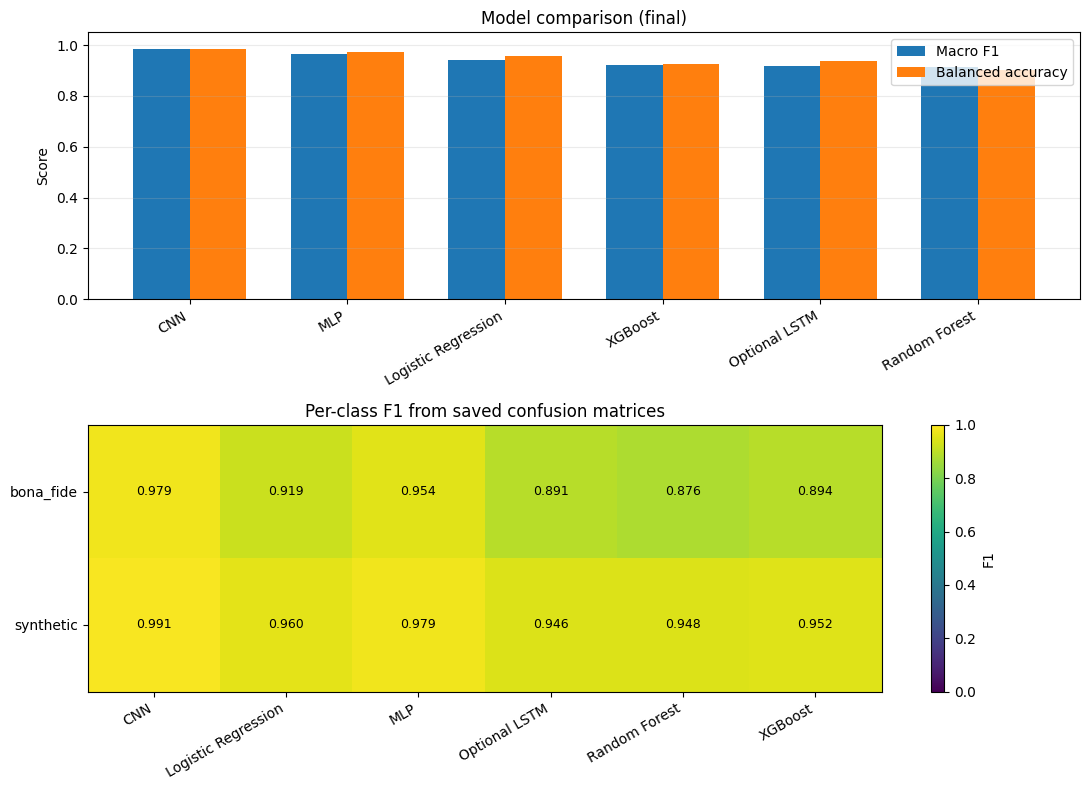

Saved comparison figure: C:\Users\PC\Documents\GitHub\Intro-to-AI\outputs\comparison\figures\model_comparison_final.png


In [8]:
figure_path = COMPARISON_FIGURES_DIR / f"model_comparison_{RUN_MODE}.png"

plot_df = comparison_df.copy()
plot_df["plot_score"] = plot_df["macro_f1"].combine_first(plot_df["f1"])
plot_df["plot_balanced_accuracy"] = plot_df["balanced_accuracy"].combine_first(plot_df["accuracy"])

optional_panels = []
if plot_df["runtime_seconds"].notna().any():
    optional_panels.append("runtime")
if plot_df["parameter_count"].notna().any():
    optional_panels.append("parameter_count")
if not per_class_metrics_df.empty:
    optional_panels.append("per_class")

n_panels = 1 + len(optional_panels)
fig, axes = plt.subplots(n_panels, 1, figsize=(11, max(5, 4 * n_panels)))
if n_panels == 1:
    axes = [axes]

ax = axes[0]
x = np.arange(len(plot_df))
width = 0.36
ax.bar(x - width / 2, plot_df["plot_score"], width, label="Macro F1" if plot_df["macro_f1"].notna().any() else "F1 fallback")
ax.bar(x + width / 2, plot_df["plot_balanced_accuracy"], width, label="Balanced accuracy" if plot_df["balanced_accuracy"].notna().any() else "Accuracy fallback")
ax.set_title(f"Model comparison ({RUN_MODE})")
ax.set_ylabel("Score")
ax.set_xticks(x)
ax.set_xticklabels(plot_df["model_name"], rotation=30, ha="right")
ax.set_ylim(0, 1.05)
ax.legend()
ax.grid(axis="y", alpha=0.25)

panel_index = 1
if "runtime" in optional_panels:
    ax = axes[panel_index]
    runtime_df = plot_df.dropna(subset=["runtime_seconds", "plot_score"])
    ax.scatter(runtime_df["runtime_seconds"], runtime_df["plot_score"], s=80)
    for _, row in runtime_df.iterrows():
        ax.annotate(row["model_name"], (row["runtime_seconds"], row["plot_score"]), textcoords="offset points", xytext=(5, 5))
    ax.set_title("Runtime vs score")
    ax.set_xlabel("Runtime seconds")
    ax.set_ylabel("Macro F1 or fallback F1")
    ax.grid(alpha=0.25)
    panel_index += 1

if "parameter_count" in optional_panels:
    ax = axes[panel_index]
    params_df = plot_df.dropna(subset=["parameter_count", "plot_score"])
    ax.scatter(params_df["parameter_count"], params_df["plot_score"], s=80)
    for _, row in params_df.iterrows():
        ax.annotate(row["model_name"], (row["parameter_count"], row["plot_score"]), textcoords="offset points", xytext=(5, 5))
    ax.set_title("Parameter count vs score")
    ax.set_xlabel("Parameter count")
    ax.set_ylabel("Macro F1 or fallback F1")
    ax.grid(alpha=0.25)
    panel_index += 1

if "per_class" in optional_panels:
    ax = axes[panel_index]
    per_class_plot = per_class_metrics_df.pivot_table(index="class_name", columns="model_name", values="f1", aggfunc="mean")
    im = ax.imshow(per_class_plot.values, aspect="auto", vmin=0, vmax=1, cmap="viridis")
    ax.set_title("Per-class F1 from saved confusion matrices")
    ax.set_xticks(np.arange(per_class_plot.shape[1]))
    ax.set_xticklabels(per_class_plot.columns, rotation=30, ha="right")
    ax.set_yticks(np.arange(per_class_plot.shape[0]))
    ax.set_yticklabels(per_class_plot.index)
    for i in range(per_class_plot.shape[0]):
        for j in range(per_class_plot.shape[1]):
            value = per_class_plot.iloc[i, j]
            if pd.notna(value):
                ax.text(j, i, f"{value:.3f}", ha="center", va="center", color="white" if value < 0.75 else "black", fontsize=9)
    fig.colorbar(im, ax=ax, label="F1")

plt.tight_layout()
fig.savefig(figure_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved comparison figure:", figure_path)

## Save Comparison Outputs

In [9]:
comparison_table_path = COMPARISON_TABLES_DIR / f"model_comparison_{RUN_MODE}.csv"
comparison_metrics_path = COMPARISON_METRICS_DIR / f"model_comparison_{RUN_MODE}.json"

comparison_display_df.to_csv(comparison_table_path, index=False)

summary_payload = {
    "created_at": datetime.now().isoformat(timespec="seconds"),
    "project_root": str(PROJECT_ROOT),
    "output_root": str(OUTPUT_ROOT),
    "run_mode": RUN_MODE,
    "expected_dataset_id": EXPECTED_DATASET_ID,
    "ranking_rule": "macro_f1 desc, then balanced_accuracy desc; fallback columns are flagged in ranking_basis",
    "comparison_table_path": str(comparison_table_path),
    "comparison_figure_path": str(figure_path),
    "loaded_results": comparison_df.where(pd.notna(comparison_df), None).to_dict(orient="records"),
    "found_metric_files": found_metrics_df.where(pd.notna(found_metrics_df), None).to_dict(orient="records"),
    "missing_results": missing_results_df.where(pd.notna(missing_results_df), None).to_dict(orient="records"),
    "skipped_files": skipped_files_df.where(pd.notna(skipped_files_df), None).to_dict(orient="records"),
    "per_class_metrics": per_class_metrics_df.where(pd.notna(per_class_metrics_df), None).to_dict(orient="records") if not per_class_metrics_df.empty else [],
}

with open(comparison_metrics_path, "w", encoding="utf-8") as handle:
    json.dump(summary_payload, handle, indent=2)

print("Saved comparison table:", comparison_table_path)
print("Saved comparison figure:", figure_path)
print("Saved comparison metrics JSON:", comparison_metrics_path)

Saved comparison table:

 C:\Users\PC\Documents\GitHub\Intro-to-AI\outputs\comparison\tables\model_comparison_final.csv
Saved comparison figure: C:\Users\PC\Documents\GitHub\Intro-to-AI\outputs\comparison\figures\model_comparison_final.png
Saved comparison metrics JSON: C:\Users\PC\Documents\GitHub\Intro-to-AI\outputs\comparison\metrics\model_comparison_final.json


## Interpreting the Ranking

The ranking is a consolidation of saved result files, not a new model-selection procedure. If final test metrics are loaded, they should be interpreted as a final reporting comparison after model choices have already been made in the individual training notebooks.

Missing models are not imputed. They remain visible in the missing-results report so that an absent SVM, optional model, or failed run cannot be confused with a poor score. Optional metrics such as runtime, parameter count, seed, or dataset metadata are displayed only when the source files provide them.

When macro metrics are not present in a metric JSON, this notebook computes them from the saved confusion matrix if one is available. If neither macro metrics nor a confusion matrix are available, the notebook keeps the raw metric values and flags any fallback ranking basis explicitly.